#Tarea 2

##Leonardo Garcia Muñoz

###Análisis de sentimientos

In [1]:
!pip install datasets -q
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
#NLTK: para tokenizar, quitar stopwords y lematizar
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.snowball import SnowballStemmer
nltk.download('stopwords')
nltk.download('punkt_tab')

#scikit-learn: para la vectorización TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

#para cargar el dataset de reseñas de Amazon
from datasets import load_dataset

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


###Usaremos el dataset de Reseñas de Amazon 2023
-El cual se puede obtener de aqui https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023

-incluye reseñas de usuarios, metadata de los productos y relaciones entre usuarios y productos.

In [4]:
#Descargamos el archivo comprimido de reseñas
url = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/All_Beauty.jsonl.gz"
!wget -q -O All_Beauty.jsonl.gz {url}

In [5]:
df = pd.read_json("All_Beauty.jsonl.gz", lines=True, compression="gzip")
df = df[['text', 'title', 'rating']].dropna()
print(f"Total de reseñas disponibles: {len(df)}")
df.head()

Total de reseñas disponibles: 701528


,text,title,rating
0,This spray is really nice. It smells really go...,Such a lovely scent but not overpowering.,5
1,"This product does what I need it to do, I just...",Works great but smells a little weird.,4
2,"Smells good, feels great!",Yes!,5
3,Felt synthetic,Synthetic feeling,1
4,Love it,A+,5


In [6]:
#El dataset completo tiene muchísimas reseñas; para que el notebook corra rápido
#en Colab tomamos una muestra aleatoria
N_MUESTRA = 5000

df = df.sample(n=N_MUESTRA, random_state=42).reset_index(drop=True)
#id único por reseña, nos va a servir más adelante para agrupar tokens por reseña
df['id_reseña'] = df.index

df.head()

,text,title,rating,id_reseña
0,"Nice formula, smooth application with no pooli...",Neon pink.,5,0
1,Great product. It came when expected.,Godd experience,5,1
2,My 90 year old mother's favorite fragrance.,Love This..made my mom's day,5,2
3,Just not worth it,Review,1,3
4,The Battery life on this product has always be...,Battery will not stay charged (Rescinding),5,4


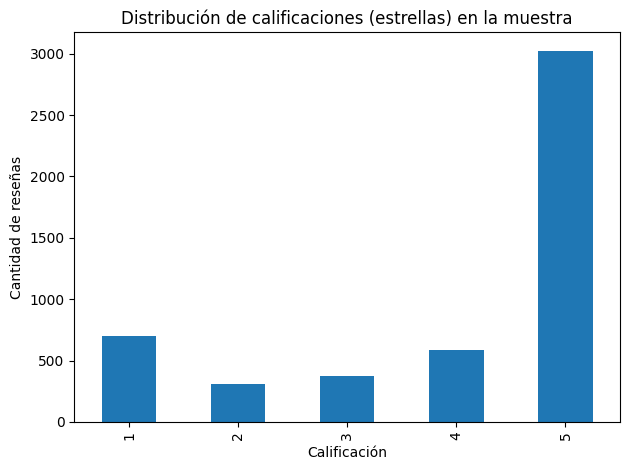

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
#como swe distribuyen las calificaciones en la muestra
import matplotlib.pyplot as plt
from google.colab import files
plt.figure()
df['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución de calificaciones (estrellas) en la muestra')
plt.xlabel('Calificación')
plt.ylabel('Cantidad de reseñas')
plt.tight_layout()
plt.savefig("distribucioncalf.png", dpi=300, bbox_inches="tight")
plt.show()
files.download("distribucioncalf.png")


In [11]:
#pasamos a minúsculas, quitamos puntuación y signos, tokenizamos y quitamos stopwords en ingles (las reseñas de este dataset están en inglés).
stop_words = set(stopwords.words('english'))
def tokenizar(texto):
    texto = str(texto).lower()
    #Quitamos todo lo que no sea letra, número o espacio (puntuación, símbolos, etc.)
    texto_limpio = re.sub(r'[^\w\s]', '', texto)
    tokens = word_tokenize(texto_limpio)
    #stopwords y tokens que sean solo números
    tokens_filtrados = [t for t in tokens if t not in stop_words and not t.isdigit()]
    return tokens_filtrados
#probamos la función con una reseña de ejemplo
tokenizar(df.loc[0, 'text'])

['nice',
 'formula',
 'smooth',
 'application',
 'pooling',
 'shink',
 'back',
 'used',
 'three',
 'coats',
 'pretty',
 'standard',
 'im',
 'sure',
 'could',
 'get',
 'away',
 'two',
 'bit',
 'streaking',
 'picture',
 'doesnt',
 'color',
 'justice',
 'much',
 'brighter',
 'person']

In [12]:
#aplicamos tokenizacion a todas las reseñas
df['tokens'] = df['text'].apply(tokenizar)
#Lematización (en este caso, stemming con Snowball)
stemmer = SnowballStemmer("english")
df['tokens_stem'] = df['tokens'].apply(lambda tokens: [stemmer.stem(t) for t in tokens])
# Reconstruimos un texto "limpio" para poder pasarlo al vectorizador TF-IDF
df['texto_limpio'] = df['tokens_stem'].apply(lambda tokens: ' '.join(tokens))
df[['text', 'tokens_stem', 'texto_limpio']].head()

,text,tokens_stem,texto_limpio
0,"Nice formula, smooth application with no pooli...","[nice, formula, smooth, applic, pool, shink, b...",nice formula smooth applic pool shink back use...
1,Great product. It came when expected.,"[great, product, came, expect]",great product came expect
2,My 90 year old mother's favorite fragrance.,"[year, old, mother, favorit, fragranc]",year old mother favorit fragranc
3,Just not worth it,[worth],worth
4,The Battery life on this product has always be...,"[batteri, life, product, alway, poor, get, one...",batteri life product alway poor get one use lo...


In [13]:
#Nos quedamos solo con reseñas que, después de limpiar, sí tengan carnita vaya
df = df[df['texto_limpio'].str.strip() != ''].reset_index(drop=True)
df['id_reseña'] = df.index
print(f"Reseñas utilizables después del preprocesamiento: {len(df)}")

Reseñas utilizables después del preprocesamiento: 4984


In [14]:
#max_features limita el vocabulario a las palabras más frecuentes
vectorizador = TfidfVectorizer(max_features=3000, min_df=2)
matriz_tfidf = vectorizador.fit_transform(df['texto_limpio'])

In [15]:
#1.Dispersión (sparsity): qué proporción de la matriz son ceros. Es normal que en TF-IDF la matriz sea muy dispersa, porque cada reseña individual solo usa una fracción pequeña de todo el vocabulario.
no_ceros = matriz_tfidf.nnz
total_celdas = matriz_tfidf.shape[0] * matriz_tfidf.shape[1]
dispersión = 1 - (no_ceros / total_celdas)
print(f"Proporción de ceros en la matriz: {dispersión:.4%}")
#2. Cuántos términos "no cero" tiene, en promedio, cada reseña
términos_por_reseña = (matriz_tfidf != 0).sum(axis=1)
print(f"Términos distintos promedio por reseña: {np.mean(términos_por_reseña):.2f}")

Proporción de ceros en la matriz: 99.5441%
Términos distintos promedio por reseña: 13.68


In [16]:
#3.Palabras con mayor IDF (más "raras"/distintivas en el corpus) vs menor IDF (más comunes, aparecen en casi todas las reseñas)
idf_por_termino = pd.DataFrame({
    'término': vectorizador.get_feature_names_out(),
    'idf': vectorizador.idf_,
}).sort_values('idf')
print("Términos más comunes en el corpus (IDF bajo):")
display(idf_por_termino.head(10))
print("\nTérminos más raros/distintivos del corpus (IDF alto):")
display(idf_por_termino.tail(10))

Términos más comunes en el corpus (IDF bajo):


,término,idf
2832,use,2.475405
1474,love,2.631751
1129,great,2.757256
1976,product,2.793969
1426,like,2.806105
1158,hair,2.858748
2951,work,2.971717
1106,good,3.058990
1459,look,3.191623
1744,one,3.287652



Términos más raros/distintivos del corpus (IDF alto):


,término,idf
2005,puedo,8.415576
2004,pued,8.415576
2003,psoriasi,8.415576
2001,proven,8.415576
2028,queda,8.415576
2984,yetbr,8.415576
7,4b,8.415576
23,access,8.415576
21,accent,8.415576
2995,yrs,8.415576


In [17]:
# 4.en una reseña de ejemplo, vemos cuáles son sus términos con mayor peso TF-IDF
idx_ejemplo = 0
fila = matriz_tfidf[idx_ejemplo].toarray().flatten()
vocabulario = vectorizador.get_feature_names_out()
top_terminos = pd.DataFrame({'término': vocabulario, 'peso_tfidf': fila})
top_terminos = top_terminos[top_terminos['peso_tfidf'] > 0].sort_values('peso_tfidf', ascending=False)
print("Reseña original:")
print(df.loc[idx_ejemplo, 'text'])
print("\nTérminos con mayor peso TF-IDF en esa reseña:")
display(top_terminos.head(10))

Reseña original:
Nice formula, smooth application with no pooling or shink back. I used three coats, which is pretty standard for me. I'm not sure you could get away with two as I did have a bit of streaking. ( Picture doesn't do the color justice, it's much brighter in person. )

Términos con mayor peso TF-IDF en esa reseña:


,término,peso_tfidf
1336,justic,0.292134
2465,standard,0.279699
333,brighter,0.274764
1919,pool,0.270411
2503,streak,0.262995
1025,formula,0.246907
516,coat,0.209325
2673,three,0.207038
124,applic,0.201553
1860,person,0.200921


In [18]:
# Cargamos el mismo léxico AFINN que se uso en clase
lexicon = pd.read_table(
    'https://raw.githubusercontent.com/fnielsen/afinn/master/afinn/data/AFINN-en-165.txt',
    names=['termino', 'sentimiento']
)
lexicon.head()


,termino,sentimiento
0,abandon,-2
1,abandoned,-2
2,abandons,-2
3,abducted,-2
4,abduction,-2


In [19]:
# 'Explotamos' la columna de tokens para tener un renglón por (reseña, token),
df_tokens = df[['id_reseña', 'rating', 'tokens']].explode('tokens')
df_tokens = df_tokens.rename(columns={'tokens': 'token'})
# Cruzamos cada token contra el léxico AFINN
df_sentimiento = pd.merge(
    left=df_tokens,
    right=lexicon,
    left_on='token',
    right_on='termino',
    how='inner',
)
df_sentimiento.head()


,id_reseña,rating,token,termino,sentimiento
0,0,5,nice,nice,3
1,0,5,pretty,pretty,1
2,0,5,justice,justice,2
3,1,5,great,great,3
4,2,5,favorite,favorite,2


In [20]:
#sumamos el puntaje de sentimiento por reseña para obtener un puntaje global
puntaje_por_reseña = (
    df_sentimiento.groupby('id_reseña')['sentimiento']
    .sum()
    .reset_index()
    .rename(columns={'sentimiento': 'puntaje_sentimiento'})
)
#lo juntamos de vuelta al dataframe principal. Las reseñas que no tengan ninguna palabra en el léxico AFINN van a quedar con NaN; las tratamos como neutras (0).
df = df.merge(puntaje_por_reseña, on='id_reseña', how='left')
df['puntaje_sentimiento'] = df['puntaje_sentimiento'].fillna(0)
#clasificamos la reseña como positiva, negativa o neutra segun el  puntaje
def clasificar_sentimiento(puntaje):
    if puntaje > 0:
        return 'positivo'
    elif puntaje < 0:
        return 'negativo'
    else:
        return 'neutro'
df['sentimiento_predicho'] = df['puntaje_sentimiento'].apply(clasificar_sentimiento)
df[['text', 'rating', 'puntaje_sentimiento', 'sentimiento_predicho']].head(10)

,text,rating,puntaje_sentimiento,sentimiento_predicho
0,"Nice formula, smooth application with no pooli...",5,6.0,positivo
1,Great product. It came when expected.,5,3.0,positivo
2,My 90 year old mother's favorite fragrance.,5,2.0,positivo
3,Just not worth it,1,2.0,positivo
4,The Battery life on this product has always be...,5,-3.0,negativo
5,When it came to me one of the shadows was brok...,1,1.0,positivo
6,Purpose: teething child<br />Overall: child li...,4,4.0,positivo
7,They look nice but do not stay on. They have n...,2,3.0,positivo
8,Good,5,3.0,positivo
9,Works great,5,3.0,positivo


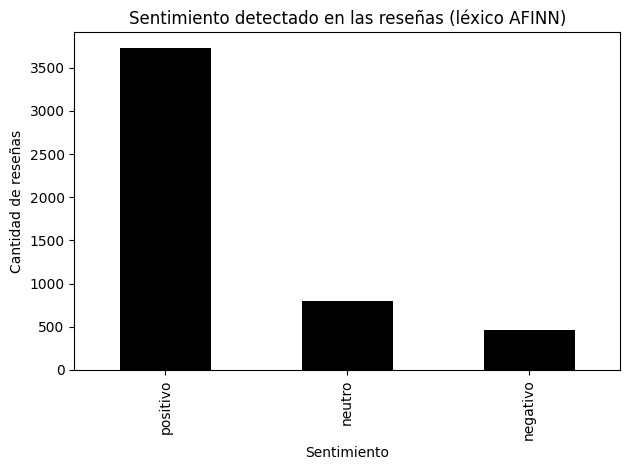

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
#distribucion general del sentimiento detectado
plt.figure()
df['sentimiento_predicho'].value_counts().plot(kind='bar', color='black')
plt.title('Sentimiento detectado en las reseñas (léxico AFINN)')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad de reseñas')
plt.tight_layout()
plt.savefig("sentimientodetectado.png", dpi=300, bbox_inches="tight")
plt.show()
files.download("sentimientodetectado.png")

<Figure size 640x480 with 0 Axes>

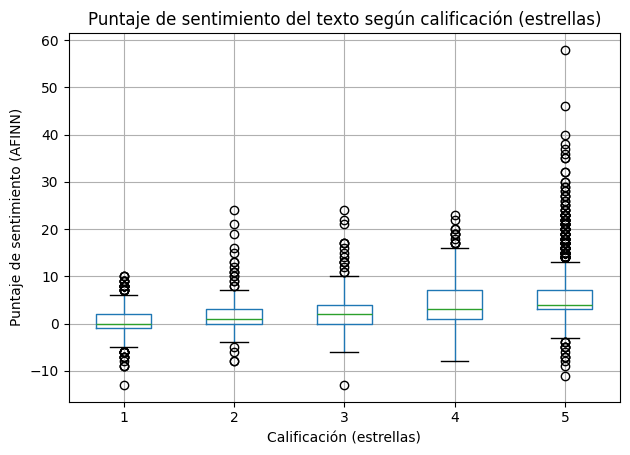

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
#relacióon entre calificación (estrellas) y puntaje de sentimiento del texto
plt.figure()
df.boxplot(column='puntaje_sentimiento', by='rating')
plt.title('Puntaje de sentimiento del texto según calificación (estrellas)')
plt.suptitle('')
plt.xlabel('Calificación (estrellas)')
plt.ylabel('Puntaje de sentimiento (AFINN)')
plt.tight_layout()
plt.savefig("puntajesentimiento.png", dpi=300, bbox_inches="tight")
plt.show()
files.download("puntajesentimiento.png")

In [25]:
#Correlacion entre el puntaje de sentimiento del texto y la calificación numerica, usamos Spearman porque 'rating' es una escala ordinal (1 a 5), no continua.
correlación = df[['rating', 'puntaje_sentimiento']].corr(method='spearman').iloc[0, 1]
print(f"Correlación (Spearman) entre calificación y sentimiento del texto: {correlación:.3f}")


Correlación (Spearman) entre calificación y sentimiento del texto: 0.419


In [26]:
#convertimos el rating en una etiqueta positiva/negativa/neutra "real", para poder compararla directamente contra el sentimiento que predijimos a partir del texto.
#Criteriosss: 4-5 estrellas = positivo, 1-2 estrellas = negativo, 3 estrellas = neutro
def rating_a_sentimiento(rating):
    if rating >= 4:
        return 'positivo'
    elif rating <= 2:
        return 'negativo'
    else:
        return 'neutro'
df['sentimiento_real'] = df['rating'].apply(rating_a_sentimiento)
#Tabla de confusion: sentimiento predicho (texto) vs sentimiento real (calificacion)
tabla_confusión = pd.crosstab(df['sentimiento_real'], df['sentimiento_predicho'])
tabla_confusión

sentimiento_predicho,negativo,neutro,positivo
sentimiento_real,,,
negativo,285,287,439
neutro,55,82,235
positivo,124,427,3050


In [27]:
#que tan seguido coincide el sentimiento del texto con el sentimiento "real" (el que se deriva de la calificación numérica)
coincidencias = (df['sentimiento_predicho'] == df['sentimiento_real']).mean()
print(f"Coincidencia entre sentimiento del texto y calificación numérica: {coincidencias:.2%}")


Coincidencia entre sentimiento del texto y calificación numérica: 68.56%
